# Week 13 - Cart Pole Experiment

## 0. Setup

In [1]:
#!pip install "gymnasium[classic-control]"
import gymnasium as gym

import matplotlib.animation
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('animation', html='jshtml')

## 1. Load Cart Pole Environment 

The CartPole (version 1) is a very simple environment composed of a cart that can move left or right, and pole placed vertically on top of it. 
The agent must move the cart left or right to keep the pole upright.


In [2]:
env = gym.make("CartPole-v1", render_mode="rgb_array")

### Observations: 
In the case of the CartPole, each observation is a 1D NumPy array composed of 4 floats: 
- the cart's horizontal position, 
- its velocity, 
- the angle of the pole (0 = vertical), 
- and the angular velocity.

### Actions: 
Your agent will need to select an action from an "action space" (the set of possible actions). There are just two possible actions: 
- accelerate towards the left (0) 
- accelerate towards the right (1).

### Rewards:
The environment also tells the agent how much reward it got during the last step. 

### Other info:
1. An environment can be visualized by calling its `render()` method. If you set `render_mode` to `"rgb_array"` when creating the environment, then this will return a NumPy array.
2. When the game is over, the environment returns `done=True`. In this case, it's not over yet.
3. Some environment wrappers may want to interrupt the environment early. For example, when a time limit is reached or when an object goes out of bounds. In this case, `truncated` will be set to `True`. In this case, it's not truncated yet
4. Finally, `info` is an environment-specific dictionary that can provide some extra information that you may find useful for debugging or for training. For example, in some games it may indicate how many lives the agent has.


In [3]:
obs, info = env.reset(seed=42)

print("Observations:",obs)
print("Action space:", env.action_space)

img = env.render()
print(img.shape)  # height, width, channels (3 = Red, Green, Blue)

Observations: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Action space: Discrete(2)
(400, 600, 3)


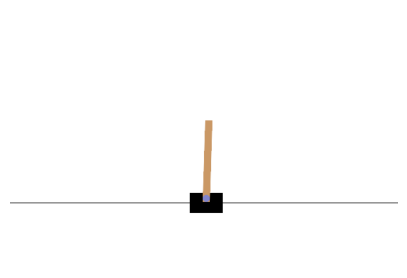

In [4]:
# extra code – creates a little function to render and plot an environment
def plot_environment(env, figsize=(5, 4)):
    plt.figure(figsize=figsize)
    img = env.render()
    plt.imshow(img)
    plt.axis("off")
    return img

plot_environment(env)
plt.show()

Let's see how to interact with an environment: 
If you accelerate the cart toward the right ``` action=1 ```
Then the pole is leaning toward the right (`obs[2] > 0`) 

In [5]:
action = 1  # accelerate right
obs, reward, done, truncated, info = env.step(action)
print(obs[2])  # pole angle>0 lean right

0.03625453


In [6]:
print("reward:",reward)
print("if done:",done)
print("if truncated:",truncated)
print("info:",info)

if done or truncated:
    obs, info = env.reset()

reward: 1.0
if done: False
if truncated: False
info: {}


# A simple hard-coded policy

Now how can we make the poll remain upright? 
Let's just hard code a simple _policy_: if the pole is tilting to the left, then push the cart to the left, and _vice versa_. Let's see if that works:

In [7]:
def basic_policy(obs):
    angle = obs[2]
    return 0 if angle < 0 else 1

totals = []
for episode in range(500):
    episode_rewards = 0
    obs, info = env.reset(seed=episode)
    for step in range(200):
        action = basic_policy(obs)
        obs, reward, done, truncated, info = env.step(action)
        episode_rewards += reward
        if done or truncated:
            break

    totals.append(episode_rewards)


import numpy as np

print("Average reward:", np.mean(totals))
print("Minimum reward:", min(totals))
print("Maximum reward:", max(totals))

Average reward: 41.698
Minimum reward: 24.0
Maximum reward: 63.0


The best it did was to keep the poll up for only 63 steps.

Let's visualize one episode. You can learn more about Matplotlib animations in the [Matplotlib tutorial notebook](tools_matplotlib.ipynb#Animations).

In [8]:
# extra code – this cell displays an animation of one episode
import matplotlib.animation

def update_scene(num, frames, patch, game_over_from, label):
    patch.set_data(frames[num])
    label.set_visible(
        game_over_from is not None and num >= game_over_from
    )
    return patch, label


def plot_animation(
    frames,
    game_over_from=None,
    repeat=False,
    interval=40
):
    fig = plt.figure()
    patch = plt.imshow(frames[0])
    plt.axis("off")

    label = plt.text(
        0.5, 0.5,
        "GAME OVER",
        transform=plt.gca().transAxes,
        ha="center",
        va="center",
        fontsize=28,
        color="red",
        weight="bold",
        bbox={"facecolor": "white", "alpha": 0.8}
    )
    label.set_visible(False)

    anim = matplotlib.animation.FuncAnimation(
        fig,
        update_scene,
        fargs=(frames, patch, game_over_from, label),
        frames=len(frames),
        repeat=repeat,
        interval=interval
    )

    plt.close()
    return anim


def show_one_episode(policy, n_max_steps=200, seed=42):
    frames = []
    game_over_from = None

    env = gym.make("CartPole-v1", render_mode="rgb_array")
    obs, info = env.reset(seed=seed)

    for step in range(n_max_steps):
        frames.append(env.render())

        action = policy(obs)
        obs, reward, terminated, truncated, info = env.step(action)

        if terminated or truncated:
            # Render the state that caused termination.
            final_frame = env.render()

            # Hold the final image for about one second.
            game_over_from = len(frames)
            frames.extend([final_frame] * 25)
            break

    env.close()

    return plot_animation(
        frames,
        game_over_from=game_over_from
    )


show_one_episode(basic_policy)

Clearly the system is unstable and after just a few wobbles, the pole ends up too tilted: game over. We will need to be smarter than that!

# Neural Network Policies

Let's create a neural network:
- Input: observations
- Output: probabilities of actions to take for each observations

To choose an action, the network will estimate a probability for each action, then we will select an action randomly according to the estimated probabilities. 
Note: This approach lets the agent find the right balance between _exploring_ new actions and _exploiting_ the actions that are known to work well.

In the case of the CartPole environment, there are just two possible actions (left or right), so we only need one output neuron: it will output the probability `p` of the action 0 (left), and of course the probability of action 1 (right) will be `1 - p`.

In [9]:
import tensorflow as tf

tf.random.set_seed(42)  # extra code – ensures reproducibility on the CPU

model = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

2026-06-20 16:39:56.351838: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-20 16:39:56.468122: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-20 16:39:56.468878: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-20 16:39:56.657087: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-20 16:39:57.767344: W tensorflow/compiler/tf

### A small policy function 
Use the neural net to get the probability of moving left, then let's use it to run one episode

In [10]:
# a function that creates an animation for a given policy model
# left_proba = probability of choosing action - "push left"
# if: left_proba = 0.7, then 70% chance choose action left

def pg_policy(obs):
    left_proba = model.predict(obs[np.newaxis], verbose=0)[0][0] 
    return int(np.random.rand() > left_proba)

#np.random.seed(42)
#show_one_episode(pg_policy)

Yeah... pretty bad. The neural network will have to learn to do better. First let's see if it is capable of learning the basic policy we used earlier: go left if the pole is tilting left, and go right if it is tilting right.

Let's see if it can learn a better policy on its own. One that does not wobble as much.

# Policy Gradients

To train this neural network we will need to define the target probabilities **y**. 
- If an action is good we should increase its probability 
- if it is bad we should reduce it. 

When the agent finally gets a reward, how do we know which previous actions should get the credit or blame? This is called the _credit assignment problem_.

在 RL 中，我们想知道哪些 action 是好的，哪些是不好的。但问题是，很多 action 的影响不是马上出现的，而是过了很多步之后才体现出来。比如一个 episode 最后成功了或失败了，我们很难判断到底是哪一步 action 导致了结果。可能是最后一步，也可能是前 10 步，也可能是很早之前的某一步。这种“如何判断每个 action 对最终结果的贡献”的问题，就叫 credit assignment problem。

RL solves this by using return and discount factor to pass future rewards backward to earlier actions.

The **_Policy Gradients_** algorithm tackles this problem by first playing multiple episodes, then making the actions near positive rewards slightly more likely, while actions near negative rewards are made slightly less likely. First we play, then we go back and think about what we did.

Let's start by creating a function to play a single step using the model. We will also pretend for now that whatever action it takes is the right one, so we can compute the loss and its gradients. We will just save these gradients for now, and modify them later depending on how good or bad the action turned out to be.

In [11]:
def play_one_step(env, obs, model, loss_fn):
    with tf.GradientTape() as tape:
        left_proba = model(obs[np.newaxis])
        action = (tf.random.uniform([1, 1]) > left_proba)
        y_target = tf.constant([[1.]]) - tf.cast(action, tf.float32)
        loss = tf.reduce_mean(loss_fn(y_target, left_proba))

    grads = tape.gradient(loss, model.trainable_variables)
    obs, reward, done, truncated, info = env.step(int(action))
    return obs, reward, done, truncated, grads

If `left_proba` is high, then `action` will most likely be `False (or 0, or go left)` so we set `y_target` to 1 - 0 = 1 (go right). 

In other words, we set the target to 1, meaning we pretend that the probability of going left should have been 100% (so we took the right action).

Now let's create another function that will rely on the `play_one_step()` function to play multiple episodes, returning all the rewards and gradients, for each episode and each step:

In [12]:
def play_multiple_episodes(env, n_episodes, n_max_steps, model, loss_fn):
    all_rewards = []
    all_grads = []
    for episode in range(n_episodes):
        current_rewards = []
        current_grads = []
        obs, info = env.reset()
        for step in range(n_max_steps):
            obs, reward, done, truncated, grads = play_one_step(
                env, obs, model, loss_fn)
            current_rewards.append(reward)
            current_grads.append(grads)
            if done or truncated:
                break

        all_rewards.append(current_rewards)
        all_grads.append(current_grads)

    return all_rewards, all_grads

The Policy Gradients algorithm uses the model to play the episode several times (e.g., 10 times), then it goes back and looks at all the rewards, discounts them and normalizes them. So let's create couple functions for that: the first will compute discounted rewards; the second will normalize the discounted rewards across many episodes.

In [13]:
def discount_rewards(rewards, discount_factor):
    discounted = np.array(rewards)
    for step in range(len(rewards) - 2, -1, -1):
        discounted[step] += discounted[step + 1] * discount_factor #r+=gamma*next_r
    return discounted

def discount_and_normalize_rewards(all_rewards, discount_factor):
    all_discounted_rewards = [discount_rewards(rewards, discount_factor)
                              for rewards in all_rewards]
    flat_rewards = np.concatenate(all_discounted_rewards)
    reward_mean = flat_rewards.mean()
    reward_std = flat_rewards.std()
    return [(discounted_rewards - reward_mean) / reward_std
            for discounted_rewards in all_discounted_rewards]

#### Call discount_rewards and normalization
Say there were 3 actions, and after each action there was a reward: first 10, then 0, then -50. If we use a discount factor of 80%, then the 3rd action will get -50 (full credit for the last reward), but the 2nd action will only get -40 (80% credit for the last reward), and the 1st action will get 80% of -40 (-32) plus full credit for the first reward (+10), which leads to a discounted reward of -22. 

To normalize all discounted rewards across all episodes, we compute the mean and standard deviation of all the discounted rewards, and we subtract the mean from each discounted reward, and divide by the standard deviation:

In [14]:
print(discount_rewards([10, 0, -50], discount_factor=0.8))

print(discount_and_normalize_rewards([[10, 0, -50], [10, 20]],
                                      discount_factor=0.8))

[-22 -40 -50]
[array([-0.28435071, -0.86597718, -1.18910299]), array([1.26665318, 1.0727777 ])]


In [15]:
n_iterations = 120
n_episodes_per_update = 5
n_max_steps = 200
discount_factor = 0.95


# extra code – let's create the neural net and reset the environment, for
#              reproducibility

tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

obs, info = env.reset(seed=42)

optimizer = tf.keras.optimizers.Nadam(learning_rate=0.01)
loss_fn = tf.keras.losses.binary_crossentropy

2026-06-20 16:40:24.757548: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2a:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-20 16:40:24.970045: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2a:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-20 16:40:24.970130: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2a:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-20 16:40:24.972807: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2a:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-20 16:40:24.972887: I external/local_xla/xla/stream_executor

In [16]:
for iteration in range(n_iterations):
    all_rewards, all_grads = play_multiple_episodes(
        env, n_episodes_per_update, n_max_steps, model, loss_fn)

    # extra code – displays some debug info during training
    total_rewards = sum(map(sum, all_rewards))
    print(f"\rIteration: {iteration + 1}/{n_iterations},"
          f" mean rewards: {total_rewards / n_episodes_per_update:.1f}", end="")

    all_final_rewards = discount_and_normalize_rewards(all_rewards,
                                                       discount_factor)
    all_mean_grads = []
    for var_index in range(len(model.trainable_variables)):
        mean_grads = tf.reduce_mean(
            [final_reward * all_grads[episode_index][step][var_index]
             for episode_index, final_rewards in enumerate(all_final_rewards)
                 for step, final_reward in enumerate(final_rewards)], axis=0)
        all_mean_grads.append(mean_grads)

    optimizer.apply_gradients(zip(all_mean_grads, model.trainable_variables))

Iteration: 120/120, mean rewards: 200.0

In [17]:
# extra code – displays the animation
np.random.seed(42)
show_one_episode(pg_policy)

I0000 00:00:1781988671.894472    1329 service.cc:145] XLA service 0x7e48e00037c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781988671.895136    1329 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-06-20 16:51:11.946875: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-20 16:51:12.006125: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1781988672.207229    1329 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
